# BiGRU Explainability Notebook

This notebook loads the CICIDS2017 sequence artifacts, restores a trained BiGRU checkpoint, and produces several explainability views:

- confusion matrix and class distribution
- saliency maps
- integrated gradients
- temporal occlusion sensitivity
- permutation-based feature importance

In [4]:
from pathlib import Path
import glob
import json

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from torch.utils.data import DataLoader, TensorDataset

ROOT = Path.cwd()
DATA_DIR = ROOT / 'artifacts' / 'preprocessed_sequences'
CHECKPOINT_PATTERN = str(ROOT / 'artifacts' / '**' / 'bigru_run*.pt')
SUMMARY_PATTERN = str(ROOT / 'artifacts' / '**' / 'summary.json')
EXCLUDED_LABELS = {13, 8, 9, 14}
EVAL_PER_CLASS = 256
IG_STEPS = 32
PERMUTATION_BATCH = 512
BATCH_SIZE = 128
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.frameon': False,
})

def load_metadata():
    with open(DATA_DIR / 'metadata.json') as f:
        return json.load(f)

metadata = load_metadata()
feature_names = metadata['feature_names']
original_classes = metadata['classes']
kept_original_ids = [idx for idx in range(len(original_classes)) if idx not in EXCLUDED_LABELS]
class_names = [original_classes[idx] for idx in kept_original_ids]
label_map = {old: new for new, old in enumerate(kept_original_ids)}

def load_split(name):
    return np.load(DATA_DIR / f'{name}.npy', mmap_mode='r')

def select_stratified_indices(y, per_class=EVAL_PER_CLASS, seed=42):
    rng = np.random.default_rng(seed)
    indices = []
    for cls in np.unique(y):
        cls_indices = np.where(y == cls)[0]
        take = min(per_class, len(cls_indices))
        indices.extend(rng.choice(cls_indices, size=take, replace=False).tolist())
    indices = np.asarray(indices, dtype=np.int64)
    rng.shuffle(indices)
    return indices

def remap_labels(y_raw):
    y_raw = np.asarray(y_raw, dtype=np.int64)
    mask = ~np.isin(y_raw, list(EXCLUDED_LABELS))
    filtered = y_raw[mask]
    remapped = np.array([label_map[int(v)] for v in filtered], dtype=np.int64)
    return mask, remapped

def materialize_subset(X_raw, raw_indices, y_values):
    X_sub = np.asarray(X_raw[raw_indices], dtype=np.float32)
    y_sub = np.asarray(y_values, dtype=np.int64)
    return torch.from_numpy(X_sub), torch.from_numpy(y_sub)

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False):
    return DataLoader(TensorDataset(X, y), batch_size=batch_size, shuffle=shuffle)

class BiGRULastState(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=1, num_classes=None, dropout=0.3):
        super().__init__()
        if num_classes is None:
            raise ValueError('num_classes must be specified')
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        out, _ = self.gru(x)
        last_out = out[:, -1, :]
        last_out = self.dropout(last_out)
        return self.fc(last_out)

def discover_checkpoint():
    summary_paths = sorted(glob.glob(SUMMARY_PATTERN, recursive=True))
    for summary_path in summary_paths:
        try:
            with open(summary_path) as f:
                summary = json.load(f)
        except Exception:
            continue
        candidate = summary.get('best_global_ckpt')
        if candidate and Path(candidate).exists():
            return Path(candidate)
    candidates = sorted(glob.glob(CHECKPOINT_PATTERN, recursive=True))
    if candidates:
        return Path(candidates[-1])
    raise FileNotFoundError('No BiGRU checkpoint found. Train bigru_ids.py first or set CHECKPOINT_PATTERN to a valid .pt file.')

def build_model(input_size, num_classes):
    model = BiGRULastState(
        input_size=input_size,
        hidden_size=256,
        num_layers=1,
        num_classes=num_classes,
        dropout=0.3,
    )
    return model.to(DEVICE)

@torch.no_grad()
def predict(model, loader):
    model.eval()
    probs_list, preds_list, true_list = [], [], []
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        probs = logits.softmax(dim=1)
        preds = probs.argmax(dim=1)
        probs_list.append(probs.cpu())
        preds_list.append(preds.cpu())
        true_list.append(yb.cpu())
    return torch.cat(probs_list).numpy(), torch.cat(preds_list).numpy(), torch.cat(true_list).numpy()

In [5]:
def plot_distribution(labels, title):
    counts = np.bincount(labels, minlength=len(class_names))
    order = np.argsort(counts)[::-1]
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.bar(np.array(class_names)[order], counts[order], color='#2a6f97')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=55)
    fig.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
    fig, ax = plt.subplots(figsize=(11, 9))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_xticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=60, ha='right')
    ax.set_yticks(np.arange(len(class_names)))
    ax.set_yticklabels(class_names)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()
    return cm


def select_representative_sample(model, X, y):
    loader = make_loader(X, y, batch_size=BATCH_SIZE, shuffle=False)
    probs, preds, true = predict(model, loader)
    correct = np.where(preds == true)[0]
    if len(correct):
        confidences = probs[correct, preds[correct]]
        idx = int(correct[np.argmax(confidences)])
    else:
        idx = int(np.argmax(probs.max(axis=1)))
    return idx, probs[idx], preds[idx], true[idx], probs, preds, true


def plot_sequence_heatmap(values, title, cmap='magma'):
    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(values, aspect='auto', origin='lower', cmap=cmap)
    ax.set_title(title)
    ax.set_xlabel('Feature')
    ax.set_ylabel('Timestep')
    step = max(1, len(feature_names) // 10)
    ax.set_xticks(np.arange(0, len(feature_names), step))
    ax.set_xticklabels([feature_names[i] for i in range(0, len(feature_names), step)], rotation=60, ha='right')
    ax.set_yticks(np.arange(values.shape[0]))
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_timestep_scores(scores, title):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(np.arange(len(scores)), scores, marker='o', color='#bb3e03')
    ax.set_title(title)
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Importance')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_top_features(scores, title, top_k=15, color='#33658a'):
    order = np.argsort(scores)[-top_k:][::-1]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(np.array(feature_names)[order][::-1], scores[order][::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('Importance')
    fig.tight_layout()
    plt.show()


def saliency_map(model, sample, target_class):
    model.eval()
    x = sample.unsqueeze(0).to(DEVICE).requires_grad_(True)
    logits = model(x)
    score = logits[0, target_class]
    model.zero_grad(set_to_none=True)
    score.backward()
    return x.grad.detach().abs().squeeze(0).cpu().numpy()


def integrated_gradients(model, sample, target_class, steps=IG_STEPS):
    model.eval()
    sample = sample.to(DEVICE)
    baseline = torch.zeros_like(sample)
    total_grads = torch.zeros_like(sample)
    alphas = torch.linspace(0.0, 1.0, steps, device=DEVICE)
    for alpha in alphas:
        x = (baseline + alpha * (sample - baseline)).detach().requires_grad_(True)
        logits = model(x.unsqueeze(0))
        score = logits[0, target_class]
        grads = torch.autograd.grad(score, x)[0]
        total_grads += grads.detach()
    attrs = ((sample - baseline) * (total_grads / steps)).detach().abs().cpu().numpy()
    return attrs


def timestep_occlusion(model, sample, target_class):
    model.eval()
    x = sample.unsqueeze(0).to(DEVICE)
    base_score = model(x)[0, target_class].item()
    drops = []
    for t in range(x.shape[1]):
        occluded = x.clone()
        occluded[:, t, :] = 0.0
        score = model(occluded)[0, target_class].item()
        drops.append(base_score - score)
    return np.asarray(drops, dtype=np.float64)


def permutation_importance(model, X_batch, y_batch):
    model.eval()
    xb = X_batch.to(DEVICE)
    yb = y_batch.to(DEVICE)
    with torch.no_grad():
        base_probs = model(xb).softmax(dim=1)
        base_score = base_probs[torch.arange(len(yb), device=DEVICE), yb].mean().item()
    scores = []
    for feat_idx in range(xb.shape[2]):
        permuted = xb.clone()
        perm_indices = torch.randperm(permuted.shape[0], device=DEVICE)
        permuted[:, :, feat_idx] = permuted[perm_indices, :, feat_idx]
        with torch.no_grad():
            perm_probs = model(permuted).softmax(dim=1)
            perm_score = perm_probs[torch.arange(len(yb), device=DEVICE), yb].mean().item()
        scores.append(base_score - perm_score)
    return np.asarray(scores, dtype=np.float64)

In [6]:
# Override checkpoint discovery paths to match current training outputs.
SUMMARY_PATTERN = str(ROOT / 'ids_bigru_output' / 'summary.json')
CHECKPOINT_PATTERN = str(ROOT / 'ids_bigru_output' / 'bigru_run*.pt')
print('SUMMARY_PATTERN =', SUMMARY_PATTERN)
print('CHECKPOINT_PATTERN =', CHECKPOINT_PATTERN)

SUMMARY_PATTERN = /home/sammarv/x-edge-esn/ids_bigru_output/summary.json
CHECKPOINT_PATTERN = /home/sammarv/x-edge-esn/ids_bigru_output/bigru_run*.pt


In [10]:
# CuDNN workaround for RNN gradient attribution in eval workflows.
def saliency_map(model, sample, target_class):
    was_training = model.training
    model.train()
    x = sample.unsqueeze(0).to(DEVICE).requires_grad_(True)
    with torch.backends.cudnn.flags(enabled=False):
        logits = model(x)
        score = logits[0, target_class]
        model.zero_grad(set_to_none=True)
        score.backward()
    if not was_training:
        model.eval()
    return x.grad.detach().abs().squeeze(0).cpu().numpy()


def integrated_gradients(model, sample, target_class, steps=IG_STEPS):
    was_training = model.training
    model.train()
    sample = sample.to(DEVICE)
    baseline = torch.zeros_like(sample)
    total_grads = torch.zeros_like(sample)
    alphas = torch.linspace(0.0, 1.0, steps, device=DEVICE)
    with torch.backends.cudnn.flags(enabled=False):
        for alpha in alphas:
            x = (baseline + alpha * (sample - baseline)).detach().requires_grad_(True)
            logits = model(x.unsqueeze(0))
            score = logits[0, target_class]
            grads = torch.autograd.grad(score, x)[0]
            total_grads += grads.detach()
    if not was_training:
        model.eval()
    attrs = ((sample - baseline) * (total_grads / steps)).detach().abs().cpu().numpy()
    return attrs

print('CuDNN attribution workaround enabled.')

CuDNN attribution workaround enabled.


Loaded checkpoint: ids_bigru_output/bigru_run7.pt
Device: cuda
Eval subset shape: (2359, 20, 70)
Classes: ['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'PortScan', 'SSH-Patator', 'Web Attack-Brute Force']


/tmp/ipykernel_3501316/982707315.py:11: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


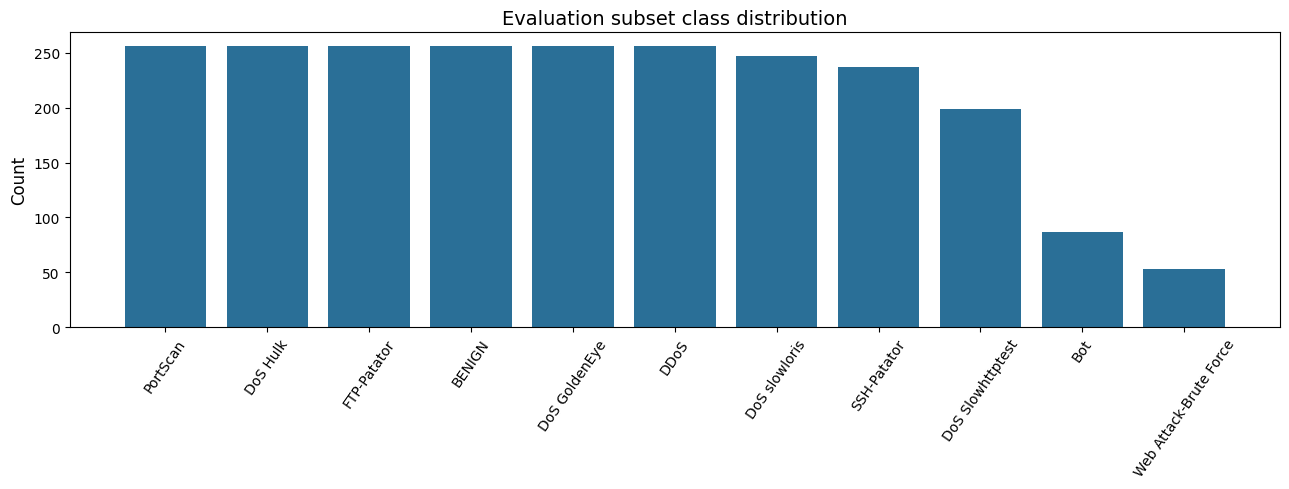

In [7]:
X_test_raw = load_split('X_test_seq')
y_test_raw = np.asarray(load_split('y_test_seq'), dtype=np.int64)
mask_test, y_test_filtered = remap_labels(y_test_raw)
filtered_indices = np.where(mask_test)[0]
sample_indices_local = select_stratified_indices(y_test_filtered, per_class=EVAL_PER_CLASS)
eval_indices = filtered_indices[sample_indices_local]
X_eval, y_eval = materialize_subset(X_test_raw, eval_indices, y_test_filtered[sample_indices_local])

checkpoint_path = discover_checkpoint()
model = build_model(input_size=metadata['n_features'], num_classes=len(class_names))
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
state_dict = checkpoint['model_state'] if isinstance(checkpoint, dict) and 'model_state' in checkpoint else checkpoint
model.load_state_dict(state_dict)
model.eval()

print(f'Loaded checkpoint: {checkpoint_path}')
print(f'Device: {DEVICE}')
print(f'Eval subset shape: {tuple(X_eval.shape)}')
print(f'Classes: {class_names}')
plot_distribution(y_eval.numpy(), 'Evaluation subset class distribution')

Accuracy: 0.7028
Macro F1:  0.7365
                        precision    recall  f1-score   support

                BENIGN       0.27      1.00      0.42       256
                   Bot       1.00      0.41      0.59        87
                  DDoS       0.99      0.69      0.81       256
         DoS GoldenEye       1.00      0.36      0.52       256
              DoS Hulk       0.97      0.41      0.58       256
      DoS Slowhttptest       1.00      0.54      0.70       199
         DoS slowloris       0.98      0.41      0.58       247
           FTP-Patator       1.00      1.00      1.00       256
              PortScan       1.00      1.00      1.00       256
           SSH-Patator       0.99      0.96      0.98       237
Web Attack-Brute Force       1.00      0.85      0.92        53

              accuracy                           0.70      2359
             macro avg       0.93      0.69      0.74      2359
          weighted avg       0.91      0.70      0.73      2359



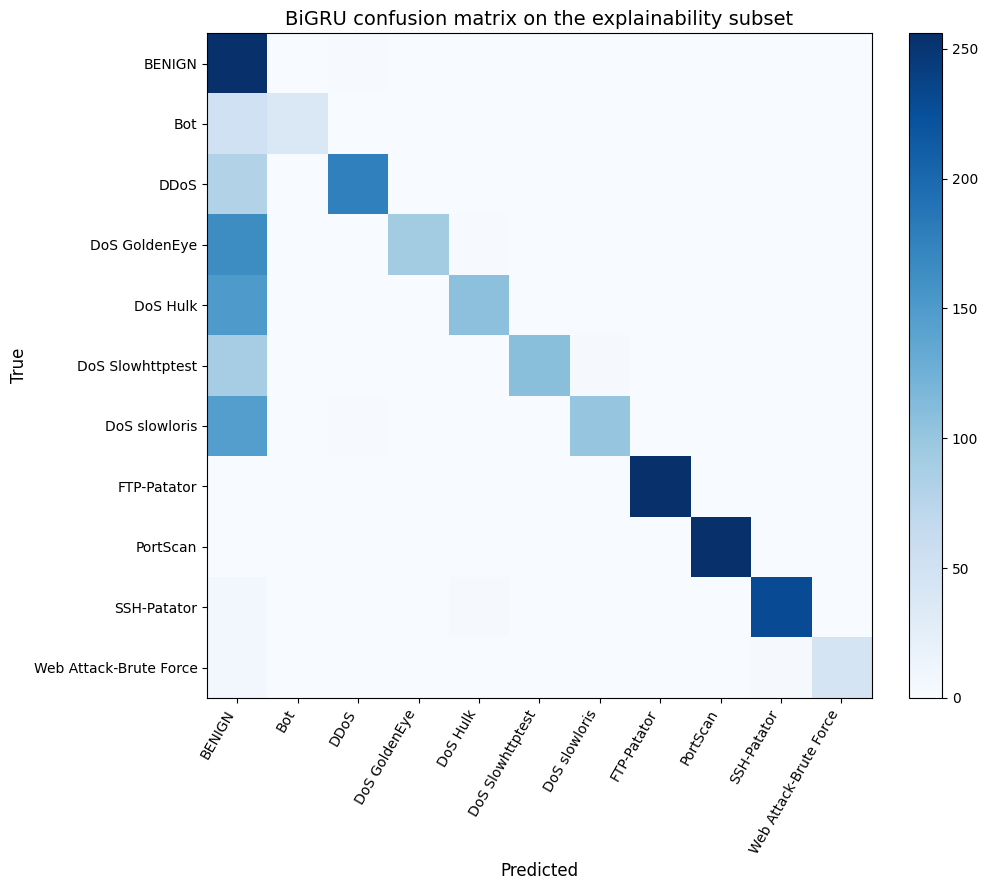

array([[255,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 51,  36,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 80,   0, 176,   0,   0,   0,   0,   0,   0,   0,   0],
       [164,   0,   0,  91,   1,   0,   0,   0,   0,   0,   0],
       [150,   0,   0,   0, 106,   0,   0,   0,   0,   0,   0],
       [ 89,   0,   0,   0,   0, 108,   2,   0,   0,   0,   0],
       [145,   0,   1,   0,   0,   0, 101,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 256,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 256,   0,   0],
       [  7,   0,   0,   0,   2,   0,   0,   0,   0, 228,   0],
       [  6,   0,   0,   0,   0,   0,   0,   0,   0,   2,  45]])

In [8]:
eval_loader = make_loader(X_eval, y_eval, batch_size=BATCH_SIZE, shuffle=False)
probs, preds, true = predict(model, eval_loader)

print(f'Accuracy: {accuracy_score(true, preds):.4f}')
print(f'Macro F1:  {f1_score(true, preds, average="macro", zero_division=0):.4f}')
print(classification_report(true, preds, target_names=class_names, zero_division=0))

plot_confusion_matrix(true, preds, title='BiGRU confusion matrix on the explainability subset')

Selected sample index: 1222
True class: BENIGN
Predicted class: BENIGN
Prediction confidence: 1.0000


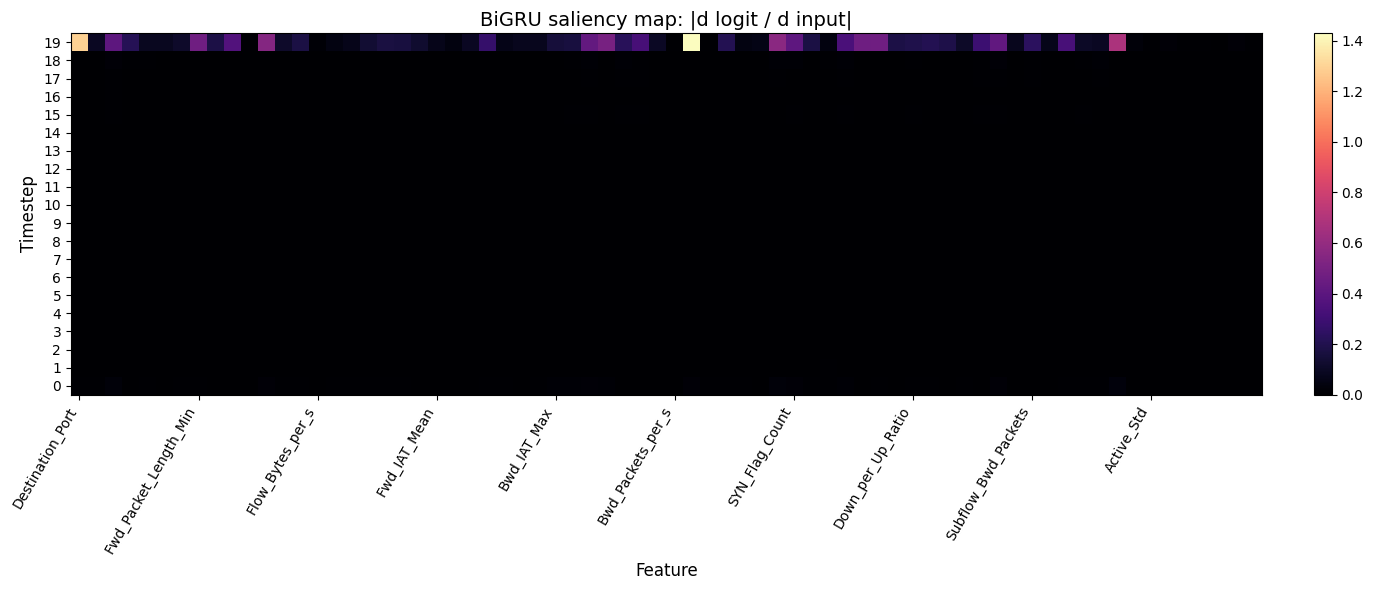

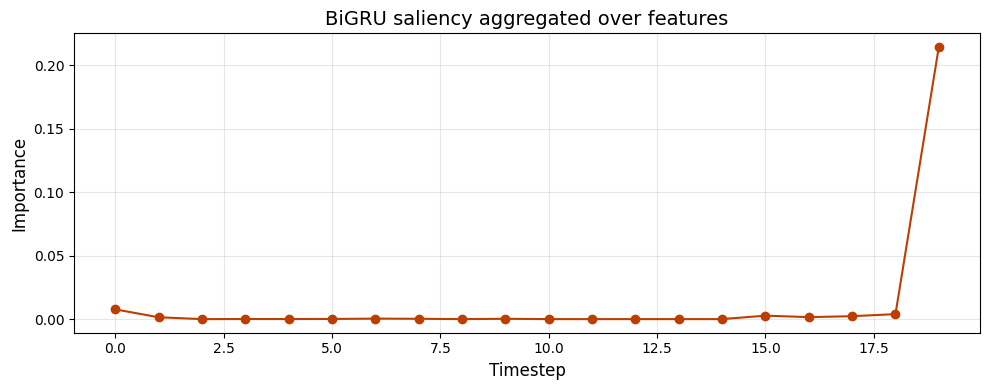

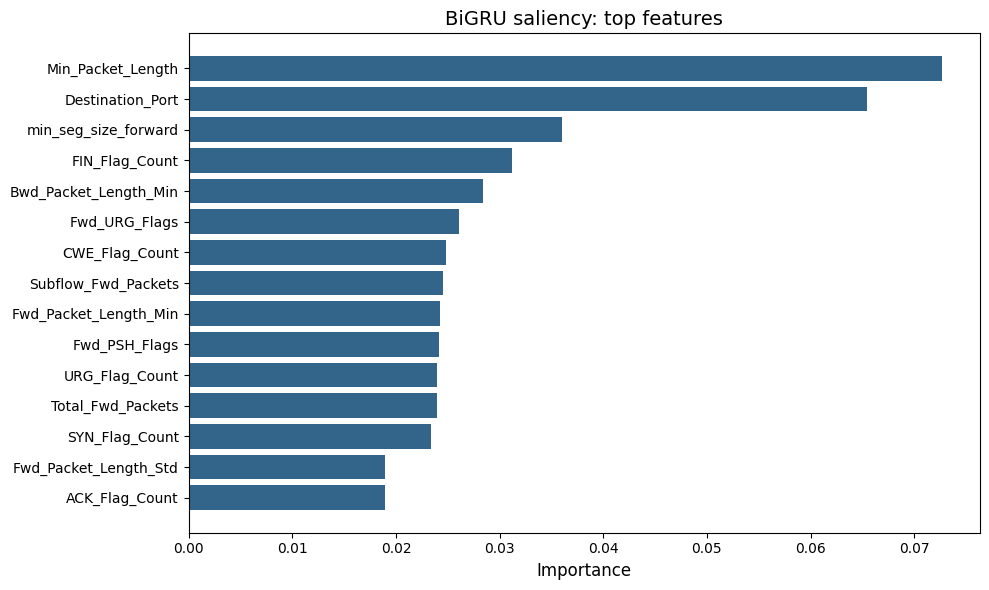

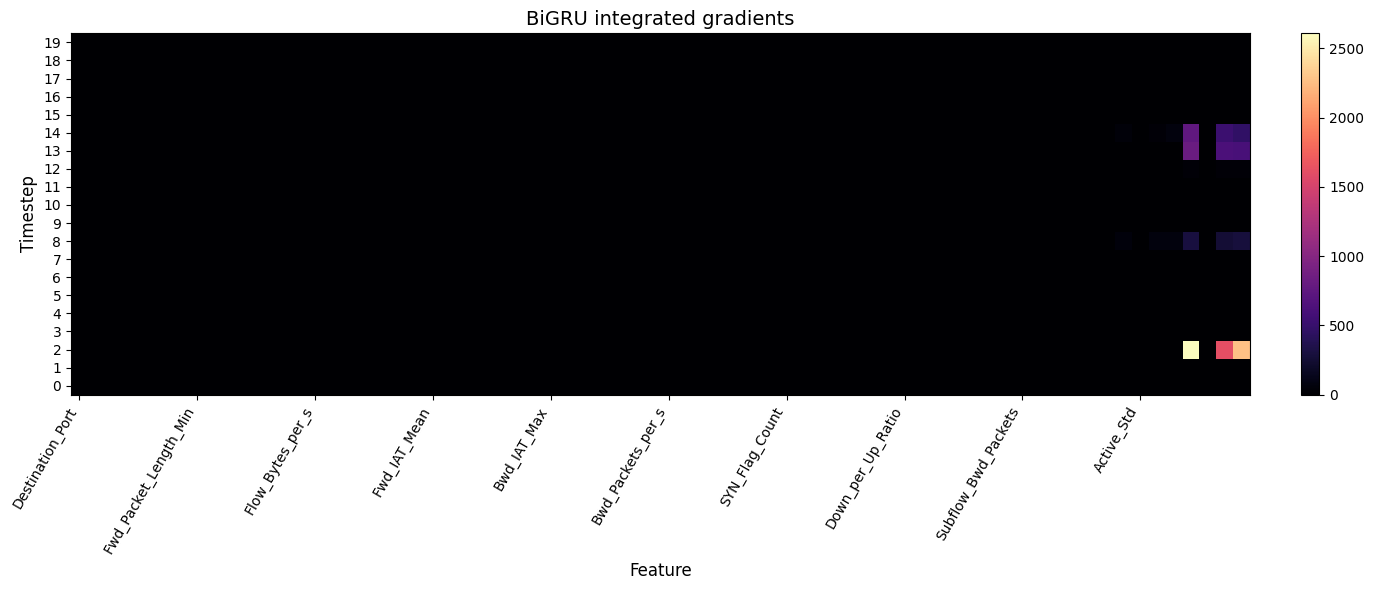

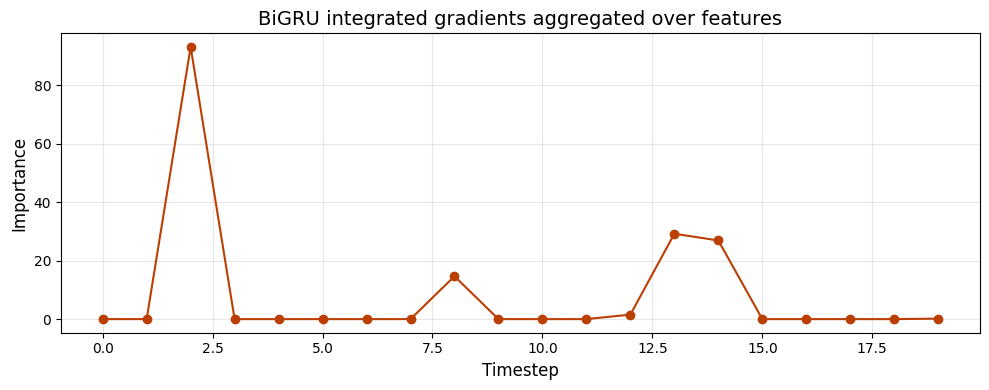

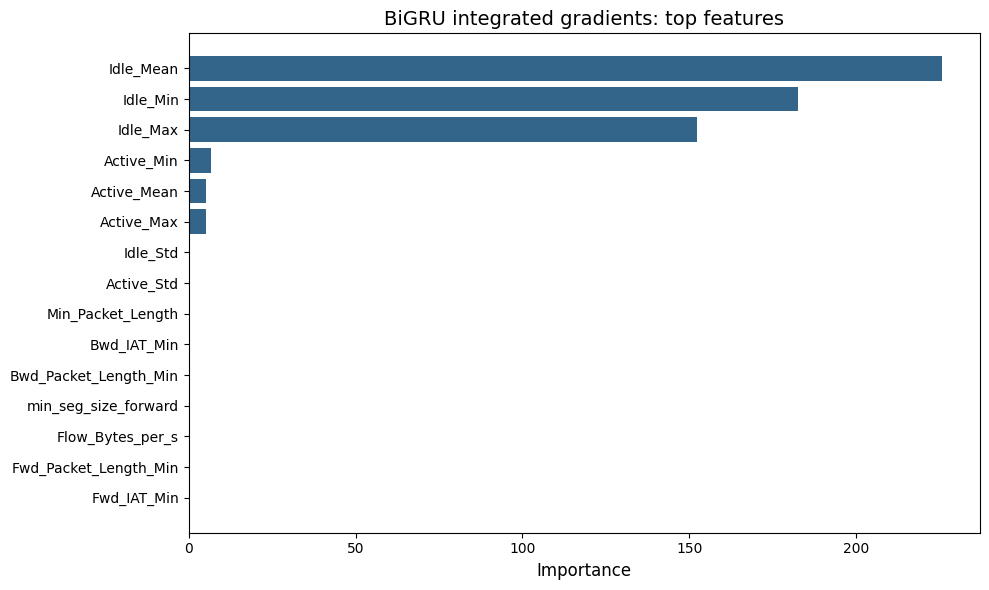

In [11]:
sample_idx, sample_probs, sample_pred, sample_true, _, _, _ = select_representative_sample(model, X_eval, y_eval)
sample = X_eval[sample_idx]
target_class = int(sample_pred)

print(f'Selected sample index: {sample_idx}')
print(f'True class: {class_names[int(sample_true)]}')
print(f'Predicted class: {class_names[target_class]}')
print(f'Prediction confidence: {float(sample_probs[target_class]):.4f}')

saliency = saliency_map(model, sample, target_class)
saliency_time = saliency.mean(axis=1)
saliency_features = saliency.mean(axis=0)

plot_sequence_heatmap(saliency, 'BiGRU saliency map: |d logit / d input|')
plot_timestep_scores(saliency_time, 'BiGRU saliency aggregated over features')
plot_top_features(saliency_features, 'BiGRU saliency: top features')

ig = integrated_gradients(model, sample, target_class, steps=IG_STEPS)
ig_time = ig.mean(axis=1)
ig_features = ig.mean(axis=0)

plot_sequence_heatmap(ig, 'BiGRU integrated gradients')
plot_timestep_scores(ig_time, 'BiGRU integrated gradients aggregated over features')
plot_top_features(ig_features, 'BiGRU integrated gradients: top features')

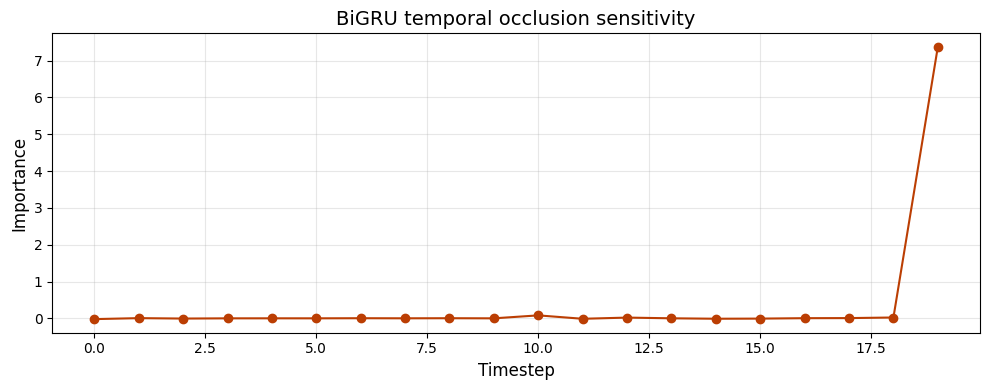

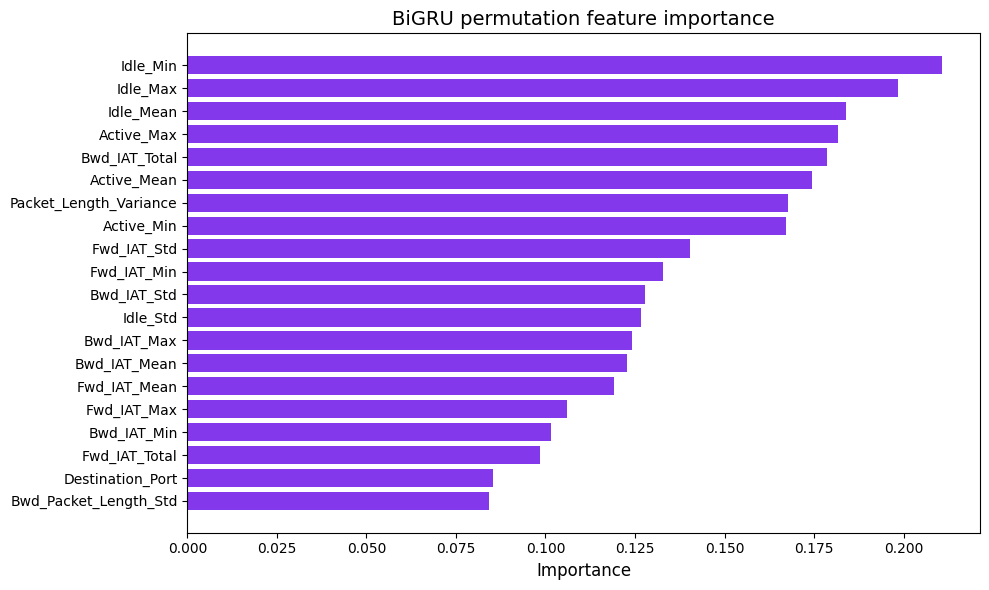

In [12]:
occlusion = timestep_occlusion(model, sample, target_class)
plot_timestep_scores(occlusion, 'BiGRU temporal occlusion sensitivity')

perm_batch = X_eval[:min(PERMUTATION_BATCH, len(X_eval))]
perm_labels = y_eval[:len(perm_batch)]
perm_scores = permutation_importance(model, perm_batch, perm_labels)
plot_top_features(perm_scores, 'BiGRU permutation feature importance', top_k=20, color='#8338ec')